In [6]:
import zipfile
import yaml
import io
import matplotlib.pyplot as plt
import cv2
import numpy as np
import seaborn as sns
import os
import glob

In [12]:
zip_path = "/srv/homes/onbo10/thesis_Ons/SurgePoseData/000000.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # video files
    video_files = [f for f in zip_ref.namelist() if f.endswith(".mp4")]
    print("Videos in zip:", video_files)
    # Yaml files
    yaml_files = [f for f in zip_ref.namelist() if "keypoints" in f.lower()]
    print("YAML files found:", yaml_files) 
    side="left"
    video_file = [f for f in video_files if side in f.lower()][0]
    print("Processing:", video_file)
    yaml_file = [f for f in yaml_files if side in f.lower()][0]
    
    # Read the video file into memory
    with zip_ref.open(video_file) as f:
        video_bytes = f.read()
    with zip_ref.open(yaml_file) as f:
        keypoints_data = yaml.safe_load(f)
    
    # Write bytes to a temporary in-memory buffer
    video_array = np.frombuffer(video_bytes, dtype=np.uint8)
    
    # OpenCV can read from memory buffer using cv2.VideoCapture with a temporary file
    tmp_path = "/tmp/temp_video.mp4"
    with open(tmp_path, "wb") as tmp_file:
        tmp_file.write(video_bytes)
    
    cap = cv2.VideoCapture(tmp_path)
    frame_count = 0
    frames = []
    while True:
        ret, frame = cap.read()
        frames.append(frame)
        if not ret:
            break
        frame_count += 1
    cap.release()
    print("Frames processed:", frame_count)
    print(len(frames))

Videos in zip: ['000000/regular/left_video.mp4', '000000/regular/right_video.mp4']
YAML files found: ['000000/keypoints_right.yaml', '000000/keypoints_left.yaml']
Processing: 000000/regular/left_video.mp4
Frames processed: 1001
1002


In [41]:

frame_id = 500
frame= frames[frame_id]

if isinstance(keypoints_data, dict):
    frame_key = list(keypoints_data.keys())[frame_id]
    keypoints = np.array(list(keypoints_data[frame_key].values()))
    print (type(keypoints))
else:
    keypoints = np.array(keypoints_data[frame_id])

print(f"Frame {frame_id} keypoints shape:", keypoints.shape)

<class 'numpy.ndarray'>
Frame 500 keypoints shape: (14, 2)


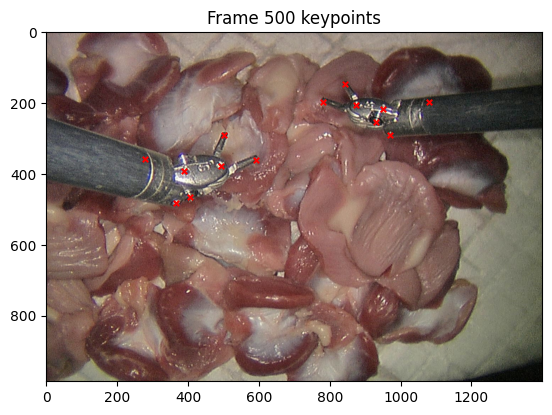

In [42]:

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.scatter(keypoints[:, 0], keypoints[:, 1], s=15, c="red", marker="x")
plt.title(f"Frame {frame_id} keypoints")
plt.show()

* Analyzing the number of keypoints across the dataset

In [17]:

lengths=[]
num=0
dir= '/srv/homes/onbo10/thesis_Ons/SurgePoseData'
kp_nums_vids=[]
for zip_path in sorted(glob.glob(f'{dir}/*.zip')):
    #print(f'in: {zip_path}')
    num+=1
    if num > 34:
        break
    else:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            yaml_file = [f for f in zip_ref.namelist() if "keypoints_left" in f.lower()][0]
            with zip_ref.open(yaml_file) as f:
                keypoints_data = yaml.safe_load(f)  
            vid_keypoints = []
            for frame in sorted(keypoints_data.keys()):  # keep frames in order
                frame_keypoints = [keypoints_data[frame][k] for k in sorted(keypoints_data[frame].keys())]  
                vid_keypoints.append(frame_keypoints)
            lens_vid=[]
            for f in vid_keypoints:
                lens_vid.append(len(f))
            lengths+=lens_vid
            kp_nums_vids.append(list(set(lens_vid)))
            #print(list(set(lens_vid)))
                
                


in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000000.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000001.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000002.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000003.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000004.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000005.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000006.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000007.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000008.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000009.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000010.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000011.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000012.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000013.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000014.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000015.zip
in: /srv/homes/onbo10/thesis_Ons/SurgePoseData/000016.zip
in: /srv/homes

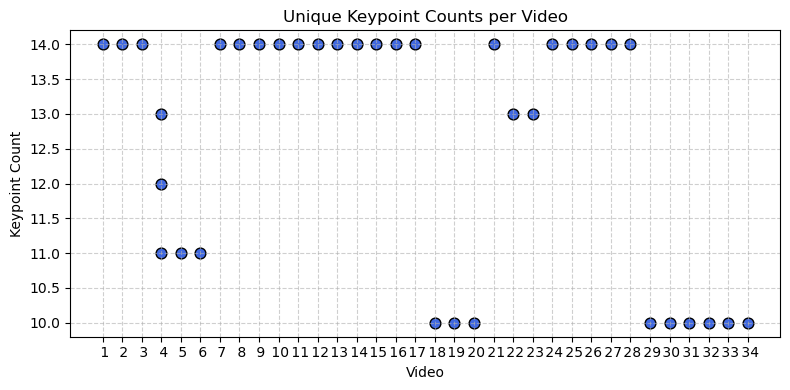

In [19]:
# SEE IF THERE IS THE SAME NUMBER OF KEYPOINTS IN ALL THE FRAMES OF EACH VIDEO

plt.figure(figsize=(8, 4))

for i, values in enumerate(kp_nums_vids, start=1):
    plt.scatter([i] * len(values), values, color='royalblue', s=60, edgecolor='black')

plt.xticks(range(1, len(kp_nums_vids) + 1), [f" {i}" for i in range(1, len(kp_nums_vids) + 1)])
plt.xlabel("Video")
plt.ylabel("Keypoint Count")
plt.title("Unique Keypoint Counts per Video")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


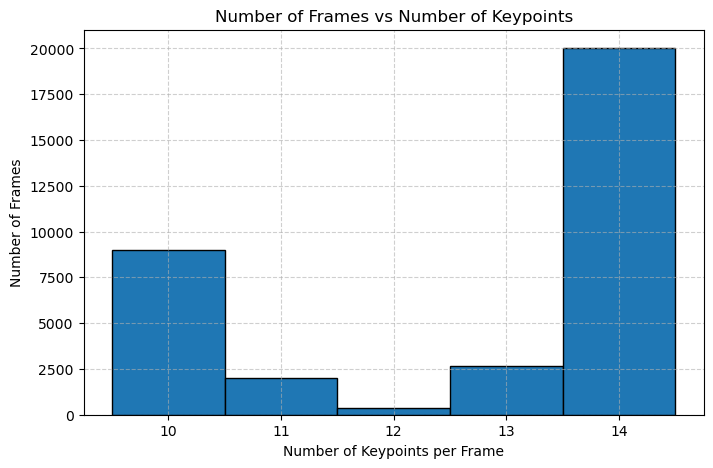

In [20]:
# Plot the histogram of the ditribution iof the number of keypoints in the set of 34 'left' videos
plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=range(min(lengths), max(lengths) + 2), align='left', edgecolor='black', density= False)
plt.title("Number of Frames vs Number of Keypoints")
plt.xlabel("Number of Keypoints per Frame")
plt.ylabel("Number of Frames")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [11]:
import glob
lengths=[]
num=0
dir= '/srv/homes/onbo10/thesis_Ons/SurgePoseData'
zip_path= dir + '/000004.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    yaml_file = [f for f in zip_ref.namelist() if "keypoints_left" in f.lower()][0]
    with zip_ref.open(yaml_file) as f:
        keypoints_data = yaml.safe_load(f)  
expected_kps = range(1, 15)
frames_sorted = sorted(keypoints_data.keys())
num_frames = len(frames_sorted)
presence_matrix = np.zeros((num_frames, len(expected_kps)), dtype=int)

for i, frame in enumerate(frames_sorted):
    frame_kps = keypoints_data[frame].keys()
    for j, kp in enumerate(expected_kps):
        presence_matrix[i, j] = 1 if kp in frame_kps else 0



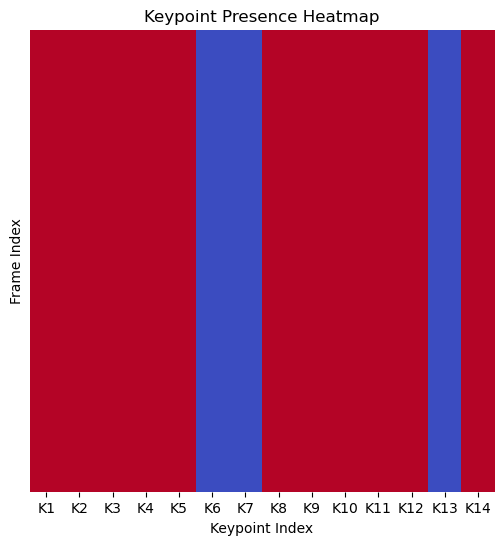

In [12]:
#RED: present, BLUE: missing
plt.figure(figsize=(6, 6))
sns.heatmap(
    presence_matrix,
    cmap='coolwarm',
    cbar=False,
    xticklabels=[f"K{kp}" for kp in expected_kps],
    yticklabels=False
)
plt.xlabel("Keypoint Index")
plt.ylabel("Frame Index")
plt.title("Keypoint Presence Heatmap")
plt.show()


+ Check Motion difference in order to select suitables frames for training

+ test to sample suitable frames from videodata

In [7]:
from tqdm import tqdm
dataset_path= "/srv/homes/onbo10/thesis_Ons/MiniSurgPose"
output_dir_jpg = dataset_path + "/Extracted/extracted_frames"
output_dir_kp = dataset_path + "/Extracted/extracted_keypoints"
T=3

num_keypoints = 14
if not os.path.exists(output_dir_jpg):
    os.makedirs(output_dir_jpg)
if not os.path.exists(output_dir_kp):
    os.makedirs(output_dir_kp)
zip_files = sorted(glob.glob(f'{dataset_path}/*.zip'))

for zip_path in tqdm(zip_files, desc="Processing videos", unit="video"):   

    vid_id = os.path.splitext(os.path.basename(zip_path))[0]
    current_jpg = os.path.join(output_dir_jpg,vid_id)
    current_kp = os.path.join(output_dir_kp,vid_id)

    if not os.path.exists(current_jpg):
        os.mkdir(current_jpg)
    if not os.path.exists(current_kp):
        os.mkdir(current_kp)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # video file
        video_file = [f for f in zip_ref.namelist() if (f.endswith(".mp4") and 'left'in f.lower())][0]
        # Yaml annotation file
        yaml_file = [f for f in zip_ref.namelist() if "keypoints_left" in f.lower()][0]
        
        with zip_ref.open(video_file) as f:
            video_bytes = f.read()
        with zip_ref.open(yaml_file) as f:
            keypoints_data = yaml.safe_load(f)

        total_frames = len(sorted(keypoints_data.keys()))
        pace = max(1, total_frames // T)

        # OpenCV can read from memory buffer using cv2.VideoCapture with a temporary file
        tmp_path = f"/tmp/{vid_id}_temp.mp4"
        with open(tmp_path, "wb") as tmp_file:
            tmp_file.write(video_bytes)
        
        cap = cv2.VideoCapture(tmp_path)
        valid_frames = sorted(keypoints_data.keys())[::pace]

        for frame_idx in valid_frames:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret:
                continue
          
            save_path = os.path.join(current_jpg, f"vid_{vid_id}_frame_{frame_idx:06d}.jpg")
            cv2.imwrite(save_path, frame)
            frame_dict = keypoints_data.get(frame_idx, {})
            #frame_dict = keypoints_data[frame_idx]
            keypoints = []
            visibility = []

            for k in range(1, num_keypoints + 1):
                if k in frame_dict:
                    keypoints.append(frame_dict[k])
                    visibility.append(1)
                else:
                    keypoints.append([0, 0])
                    visibility.append(0)
            ann_path = os.path.join(current_kp, f"vid_{vid_id}_frame_{frame_idx:06d}.yaml")

            ann_data = {"video_id": vid_id,
                        "frame_id": frame_idx,
                        "keypoints": keypoints,      
                        "visibility": visibility   
                    }

            with open(ann_path, 'w') as f:
                yaml.safe_dump(ann_data, f)
        cap.release()
        os.remove(tmp_path)

Processing videos: 100%|██████████| 2/2 [00:05<00:00,  2.60s/video]


In [3]:
zip_path = "/srv/homes/onbo10/thesis_Ons/SurgePoseData/000000.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    yaml_file = [f for f in zip_ref.namelist() if "keypoints_left" in f.lower()][0]
    with zip_ref.open(yaml_file) as f:
        keypoints_data = yaml.safe_load(f)  
        vid_keypoints = []
    for frame in sorted(keypoints_data.keys()):  # keep frames in order
        frame_keypoints = [keypoints_data[frame][k] for k in sorted(keypoints_data[frame].keys())]  
        
print('frame: ', frame_keypoints)     

frame:  [[963, 682], [855, 714], [780, 715], [702, 790], [691, 774], [842, 752], [884, 775], [223, 151], [340, 190], [445, 177], [562, 230], [561, 253], [362, 270], [324, 284]]


In [11]:
base=''
img_root='/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted/extracted_frames'
video_id = sorted(os.listdir(img_root))[0]
img_dir = os.path.join(img_root, video_id)
print(img_dir)

           
img_name= sorted(os.listdir(img_dir))[0]
print(img_name)
if img_name.endswith(".jpg"):
    base = os.path.splitext(img_name)[0]
base

/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted/extracted_frames/000000
vid_000000_frame_000000.jpg


'vid_000000_frame_000000'

+ Analyze image size